# 3 · Report Figures (standalone)

**Chameleon Predictor reproducibility notebook — 3 of 3**  
*generate → calculate → **plot***

Point this at the **per-conformer CSV from Notebook 2** and it renders four **distribution-focused** figures over the unique-conformer set for the R/S pair. It reads only that one file.

**Geometry-first:** the plots show the *distribution* of each descriptor over the unique conformers — boxplots, medians, IQRs, min/max ranges, and every point. Central lines are the **median** (not a Boltzmann-weighted mean); the lowest-energy conformer is an optional faint **QC** ring.

This notebook is **standalone**: the plotting code is inlined below — no `scripts/` import.

> Matplotlib figures only — the PyMOL 3D-ensemble views are intentionally not part of this notebook.

## Requirements
Any machine with **`pandas`, `matplotlib`, `scipy`** (+ `rdkit` for Fig 1's 2D descriptors) and a Jupyter kernel — no external binaries, no `scripts/` folder. On this repository use the **`base`** conda env.

```
conda create -n chameleon -c conda-forge python=3.11 rdkit numpy pandas matplotlib scipy jupyter ipykernel
```

## Inlined plotting library
The four figure functions and their helpers, copied from `plot_isomer_figures.py` so this notebook stands alone. Figure titles use a `TITLE` variable (set in Step 1) instead of a hardcoded scaffold name, so they work for any molecule. Run this cell once.

> If the figures change, edit the repo script and re-inline — this cell is a copy, not a live import.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
RDLogger.DisableLog('rdApp.*')

COL = {"R": "#d1495b", "S": "#30638e"}
LBL = {"rg": "Rg", "asph": "asphericity", "sphe": "spherocity", "psa": "3D-PSA",
       "SA_HD": "SA_HD", "SA_HA": "SA_HA", "hydrophobic": "hydrophobic SASA",
       "amphi": "amphi. moment", "IMHB": "IMHB", "IMHB_bb": "IMHB backbone",
       "IMHB_res": "IMHB side-chain", "IMHBD": "IMHB donors", "IMHBA": "IMHB acceptors"}
KEY_DESCRIPTORS = [("psa", "SA 3D-PSA (Å²)"), ("rg", "radius of gyration (Å)")]
SOLVENTS = ["water", "mem"]
QC_RING = "#1f3b73"   # faint ring for the lowest-energy conformer (secondary QC)


def _pt(n, big, small, cut=120):
    """Adaptive (marker size, alpha): small + transparent when there are many conformers
    (reads as a density cloud), big + opaque when few (the ~20 dedup case)."""
    return (small, 0.22) if n > cut else (big, 0.6)


def med3d(df, col):
    """Median of a descriptor over the conformers (unweighted)."""
    v = df[col].dropna().to_numpy(float)
    return float(np.median(v)) if v.size else float("nan")


def two_d(smiles):
    m = Chem.MolFromSmiles(smiles)
    return {"MolWt": Descriptors.MolWt(m), "TPSA": Descriptors.TPSA(m),
            "cLogP": Crippen.MolLogP(m), "HBD": rdMolDescriptors.CalcNumHBD(m),
            "HBA": rdMolDescriptors.CalcNumHBA(m),
            "RotB": rdMolDescriptors.CalcNumRotatableBonds(m),
            "FrCSP3": rdMolDescriptors.CalcFractionCSP3(m)}


def _reldiff(a, b):
    den = (abs(a) + abs(b)) / 2
    return float("nan") if den == 0 else 100 * abs(a - b) / den


def _sig_stars(p):
    if p is None:
        return ""
    return ("****" if p <= 1e-4 else "***" if p <= 1e-3 else
            "**" if p <= 1e-2 else "*" if p <= 0.05 else "ns")


def _color_box(bp, iso):
    """Open box (transparent face so dots show through), colored edge/median/whiskers."""
    c = COL[iso]
    for b in bp["boxes"]:
        b.set_facecolor("none"); b.set_edgecolor(c); b.set_linewidth(1.6); b.set_zorder(3)
    for m in bp["medians"]:
        m.set_color(c); m.set_linewidth(1.8); m.set_zorder(3.1)
    for w in bp["whiskers"]:
        w.set_color(c); w.set_linewidth(1.2)
    for cp in bp["caps"]:
        cp.set_color(c); cp.set_linewidth(1.2)


def _qc_ring(ax, x, y, sub, s):
    """Ring the lowest-energy conformer (highest Boltzmann weight) as secondary QC."""
    if not SHOW_ENERGY_QC or "w" not in sub or not sub["w"].notna().any():
        return
    qc = int(np.nanargmax(sub["w"].to_numpy(float)))
    ax.scatter([x[qc]], [y[qc]], s=s, facecolor="none", edgecolor=QC_RING,
               linewidth=1.4, alpha=0.85, zorder=5)


def _key_panel(ax, dfR, dfS, col, solv):
    """Distribution of one descriptor over the conformers, R vs S."""
    rng = np.random.default_rng(0)
    meds = {}
    for pos, iso, df in ((1, "R", dfR), (2, "S", dfS)):
        sub = df[df.solvent == solv].dropna(subset=[col])
        vals = sub[col].to_numpy(float)
        if vals.size == 0:
            continue
        _color_box(ax.boxplot([vals], positions=[pos], widths=0.42,
                              patch_artist=True, showfliers=False), iso)
        x = rng.normal(pos, 0.08, size=vals.size)
        s, al = _pt(vals.size, big=32, small=9)
        ax.scatter(x, vals, s=s, color=COL[iso], alpha=al, edgecolor="white",
                   linewidth=0.2, zorder=2)
        meds[iso] = float(np.median(vals))
        _qc_ring(ax, x, vals, sub, s=95)
    p = None
    try:
        from scipy.stats import mannwhitneyu
        a = dfR[dfR.solvent == solv][col].dropna().to_numpy(float)
        b = dfS[dfS.solvent == solv][col].dropna().to_numpy(float)
        if a.size and b.size:
            p = mannwhitneyu(a, b, alternative="two-sided").pvalue
    except Exception:
        p = None
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    yb = y1 + 0.05 * span
    ax.plot([1, 1, 2, 2], [yb - 0.02 * span, yb, yb, yb - 0.02 * span], color="k", lw=0.9)
    ax.text(1.5, yb + 0.005 * span, _sig_stars(p), ha="center", va="bottom", fontsize=10)
    ax.set_ylim(y0, yb + 0.12 * span)
    ax.set_xlim(0.5, 2.5)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["R", "S"], fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8.5)
    return meds


def _median_row(ax, meds):
    from matplotlib.transforms import blended_transform_factory
    tr = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(0.5, -0.17, "median", transform=ax.transAxes, ha="left", va="top",
            fontsize=7.5, color="0.35", style="italic")
    for pos, iso in ((1, "R"), (2, "S")):
        if iso in meds:
            ax.text(pos, -0.17, f"{meds[iso]:.1f}", transform=tr, ha="center", va="top",
                    fontsize=8.5, color=COL[iso], fontweight="bold")


def fig_reldiff(pair, dfR, dfS, smiR, smiS):
    two_R, two_S = two_d(smiR), two_d(smiS)
    rows = [(f"2D: {k}", _reldiff(two_R[k], two_S[k]), "#9aa0a6") for k in two_R]
    fam_col = {"IMHB": "#2a9d8f", "IMHB_bb": "#2a9d8f", "IMHB_res": "#2a9d8f",
               "IMHBD": "#2a9d8f", "IMHBA": "#2a9d8f",
               "psa": "#e76f51", "SA_HD": "#e76f51", "SA_HA": "#e76f51",
               "hydrophobic": "#e76f51", "amphi": "#e76f51",
               "rg": "#e9c46a", "asph": "#e9c46a", "sphe": "#e9c46a"}
    wR, wS = dfR[dfR.solvent == "water"], dfS[dfS.solvent == "water"]
    for col in ["IMHB", "IMHB_bb", "IMHB_res", "IMHBD", "IMHBA",
                "psa", "SA_HD", "SA_HA", "hydrophobic", "amphi", "rg", "asph", "sphe"]:
        rows.append((f"3D: {LBL[col]}", _reldiff(med3d(wR, col), med3d(wS, col)),
                     fam_col[col]))   # 3D rows use the median over the conformers
    rows = [r for r in rows if not np.isnan(r[1])]
    rows.sort(key=lambda r: r[1])
    labels, vals, colors = zip(*rows)
    fig, ax = plt.subplots(figsize=(7.5, 0.34 * len(rows) + 1))
    ax.barh(range(len(rows)), vals, color=colors)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("relative |R − S| difference (%, water phase, medians)")
    ax.set_title(f"{TITLE}: 2D blind, 3D resolves the stereocenter")
    ax.axvline(0, color="k", lw=0.6)
    fig.tight_layout()
    _save(fig, pair, "fig1_reldiff")


def fig_key_descriptors(pair, dfR, dfS):
    solv_cols = [("water", "water"), ("mem", "chloroform")]
    nrows, ncols = len(KEY_DESCRIPTORS), len(solv_cols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows), squeeze=False)
    for i, (col, label) in enumerate(KEY_DESCRIPTORS):
        for j, (solv_key, solv_lab) in enumerate(solv_cols):
            ax = axes[i][j]
            meds = _key_panel(ax, dfR, dfS, col, solv_key)
            _median_row(ax, meds)
            if i == 0:
                ax.set_title(solv_lab, fontsize=12, fontweight="bold", pad=8)
            if j == 0:
                ax.set_ylabel(label, fontsize=10.5)
    fig.suptitle(f"{TITLE}: 3D descriptor distributions, R vs S", fontsize=13, fontweight="bold")
    fig.text(0.5, 0.005, "box = IQR (25-75th) with median; whiskers = 1.5×IQR; dots = all conformers; "
             "ring = lowest-energy conformer (QC, secondary); median printed below; "
             "Mann-Whitney U over conformers, R vs S "
             "(* ≤0.05, ** ≤0.01, *** ≤0.001, **** ≤0.0001)",
             ha="center", fontsize=7.5, color="0.30")
    fig.tight_layout(rect=[0, 0.035, 1, 0.95], h_pad=2.4, w_pad=2.0)
    _save(fig, pair, "fig2_key3d")


def fig_imhb(pair, dfR, dfS):
    solv_cols = [("water", "water"), ("mem", "chloroform")]
    allc = pd.concat([dfR, dfS]).dropna(subset=["IMHB_bb"])
    cmax = int(round(allc["IMHB_bb"].max())) if len(allc) else 4
    counts = list(range(0, cmax + 1))
    width = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.9), squeeze=False, sharey=True)
    for j, (sk, sl) in enumerate(solv_cols):
        ax = axes[0][j]
        for off, iso, df in ((-width / 2, "R", dfR), (width / 2, "S", dfS)):
            sub = df[df.solvent == sk].dropna(subset=["IMHB_bb"])
            if sub.empty:
                continue
            c = np.round(sub["IMHB_bb"].to_numpy(float))
            n = c.size
            frac = [100 * (c == k).sum() / n if n else 0 for k in counts]   # unweighted fraction
            ax.bar(np.array(counts) + off, frac, width, color=COL[iso], alpha=0.85,
                   edgecolor="white", linewidth=0.6, label=iso, zorder=2)
            md = float(np.median(c)) if n else np.nan
            ax.axvline(md, color=COL[iso], ls="--", lw=1.4, alpha=0.8, zorder=3)
            ax.text(md, 102, f"{md:.1f}", color=COL[iso], ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold")
        ax.set_title(sl, fontsize=12, fontweight="bold")
        ax.set_xticks(counts); ax.set_ylim(0, 108)
        ax.set_xlabel("backbone (transannular) IMHB count", fontsize=10)
        if j == 0:
            ax.set_ylabel("fraction of conformers (%)", fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=9)
    axes[0][0].legend(frameon=False, fontsize=10, loc="upper left")
    fig.suptitle(f"{TITLE}: backbone IMHB population, R vs S", fontsize=13, fontweight="bold")
    fig.text(0.5, 0.005, "bars = fraction of conformers at each transannular backbone H-bond "
             "count (unweighted); dashed line = median count",
             ha="center", fontsize=7.5, color="0.30")
    fig.tight_layout(rect=[0, 0.04, 1, 0.93])
    _save(fig, pair, "fig3_imhb")


def _pmi_panel(ax, dfR, dfS, solv):
    """Normalized PMI triangle: NPR1 (x) vs NPR2 (y); Rod (0,1) / Sphere (1,1) / Disc (0.5,0.5)."""
    ax.plot([0, 1, 0.5, 0], [1, 1, 0.5, 1], color="0.25", lw=2.0, zorder=1)
    ax.text(0.02, 1.01, "Rod", ha="left", va="bottom", fontsize=15, color="0.25")
    ax.text(0.98, 1.01, "Sphere", ha="right", va="bottom", fontsize=15, color="0.25")
    ax.text(0.50, 0.515, "Disc", ha="center", va="bottom", fontsize=15, color="0.25")
    for pos, iso, df in ((1, "R", dfR), (2, "S", dfS)):
        sub = df[df.solvent == solv].dropna(subset=["npr1", "npr2"])
        if sub.empty:
            continue
        v = sub[["npr1", "npr2"]].to_numpy(float)
        s, al = _pt(v.shape[0], big=90, small=16)
        rug_al = 0.2 if v.shape[0] > 120 else 0.5
        ax.scatter(v[:, 0], v[:, 1], s=s, color=COL[iso],
                   alpha=al, edgecolor="white", linewidth=0.4, zorder=3, label=iso)
        yb = 0.452 if iso == "R" else 0.438
        ax.plot(v[:, 0], np.full(len(v), yb), "|", color=COL[iso], ms=8, alpha=rug_al, zorder=2)
        xb = 0.008 if iso == "R" else 0.022
        ax.plot(np.full(len(v), xb), v[:, 1], "_", color=COL[iso], ms=8, alpha=rug_al, zorder=2)
        _qc_ring(ax, v[:, 0], v[:, 1], sub, s=170)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(0.42, 1.06)
    ax.set_xlabel("NPR1 (I₁/I₃)", fontsize=17)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0]); ax.set_yticks([0.5, 0.75, 1.0])
    ax.tick_params(labelsize=14)
    ax.grid(True, color="0.92", lw=1.0, zorder=0)
    ax.set_axisbelow(True)


def fig_pmi(pair, dfR, dfS):
    solv_cols = [("water", "water"), ("mem", "chloroform")]
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 6.6), squeeze=False)
    for j, (solv_key, solv_lab) in enumerate(solv_cols):
        ax = axes[0][j]
        _pmi_panel(ax, dfR, dfS, solv_key)
        ax.set_title(solv_lab, fontsize=20, fontweight="bold")
        if j == 0:
            ax.set_ylabel("NPR2 (I₂/I₃)", fontsize=17)
    h = [plt.Line2D([], [], marker="o", ls="", color=COL[i], label=i) for i in ("R", "S")]
    axes[0][0].legend(handles=h, loc="lower left", frameon=False, fontsize=15,
                      handletextpad=0.3, bbox_to_anchor=(0.0, 0.02))
    fig.suptitle(f"{TITLE}: conformational shape space (PMI), R vs S",
                 fontsize=20, fontweight="bold")
    fig.text(0.5, 0.005, "normalized principal moments of inertia; dots = all conformers; "
             "rug = same set; ring = lowest-energy conformer (QC, secondary)",
             ha="center", fontsize=12, color="0.30")
    fig.tight_layout(rect=[0, 0.04, 1, 0.92])
    _save(fig, pair, "fig4_pmi")


def _save(fig, pair, role):
    """Write the figure to the OUT_FIG folder set in Step 1 (600-dpi PNG + vector SVG)."""
    OUT_FIG.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT_FIG / f"{role}.svg", bbox_inches="tight")
    fig.savefig(OUT_FIG / f"{role}.png", dpi=600, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved {role}.svg / .png")

print("plotting library loaded (distribution-focused, adaptive markers)")

plotting library loaded (distribution-focused, adaptive markers)


## Step 1 — point at Notebook 2's per-conformer CSV
Set `PERCONF_CSV` to the file Notebook 2 wrote. `_find` locates it whether you run from the repo root or the notebook folder; for your own data set an absolute path. `TITLE` prefixes the figure titles (set it to your molecule's name); `OUT_FIG` is where the figures are written.

In [2]:
from pathlib import Path

# ── edit these ─────────────────────────────────────────────────────────
PERCONF_CSV     = "results/notebook_descriptors/per_conformer_3-12-8-12.csv"
TITLE           = None    # figure-title prefix; None = use the pair label from the CSV
SHOW_ENERGY_QC  = True     # ring the lowest-energy conformer as a faint secondary QC marker

def _find(path):
    """Return the path if it exists, else look for it upward from the cwd. Locates DATA only."""
    p = Path(path)
    if p.exists():
        return p
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / path).exists():
            return base / path
    return p

df = pd.read_csv(_find(PERCONF_CSV))
PAIR = str(df["pair"].iloc[0])
TITLE = TITLE or PAIR
dfR = df[df.isomer == "R"].reset_index(drop=True)
dfS = df[df.isomer == "S"].reset_index(drop=True)
smiR, smiS = dfR["smiles"].iloc[0], dfS["smiles"].iloc[0]
OUT_FIG = Path("results/figures/isomers") / PAIR
print(f"pair {PAIR}:  R = {len(dfR)} conformers,  S = {len(dfS)} conformers")
print(f"title  = {TITLE!r}   |   energy QC marker = {SHOW_ENERGY_QC}")
print(f"figures -> {OUT_FIG}")

pair 3-12-8-12:  R = 1009 conformers,  S = 639 conformers
title  = '3-12-8-12'   |   energy QC marker = True
figures -> results\figures\isomers\3-12-8-12


## Step 2 — render the four figures
- **Fig 1** relative |R − S| difference (medians) — 2D blind, 3D resolves the stereocentre.
- **Fig 2** SA 3D-PSA and Rg **distributions** (boxplots + all points + median), R vs S, per solvent.
- **Fig 3** backbone IMHB population — **unweighted** fraction of unique conformers, median count.
- **Fig 4** PMI shape space — every unique conformer scattered in the rod / disc / sphere triangle.

In [3]:
fig_reldiff(PAIR, dfR, dfS, smiR, smiS)   # fig1
fig_key_descriptors(PAIR, dfR, dfS)       # fig2
fig_imhb(PAIR, dfR, dfS)                   # fig3
fig_pmi(PAIR, dfR, dfS)                    # fig4
print("done ->", OUT_FIG)

  saved fig1_reldiff.svg / .png


  saved fig2_key3d.svg / .png


  saved fig3_imhb.svg / .png


  saved fig4_pmi.svg / .png
done -> results\figures\isomers\3-12-8-12


## Step 3 — display the rendered figures

**Fig 1 — relative |R − S| difference**

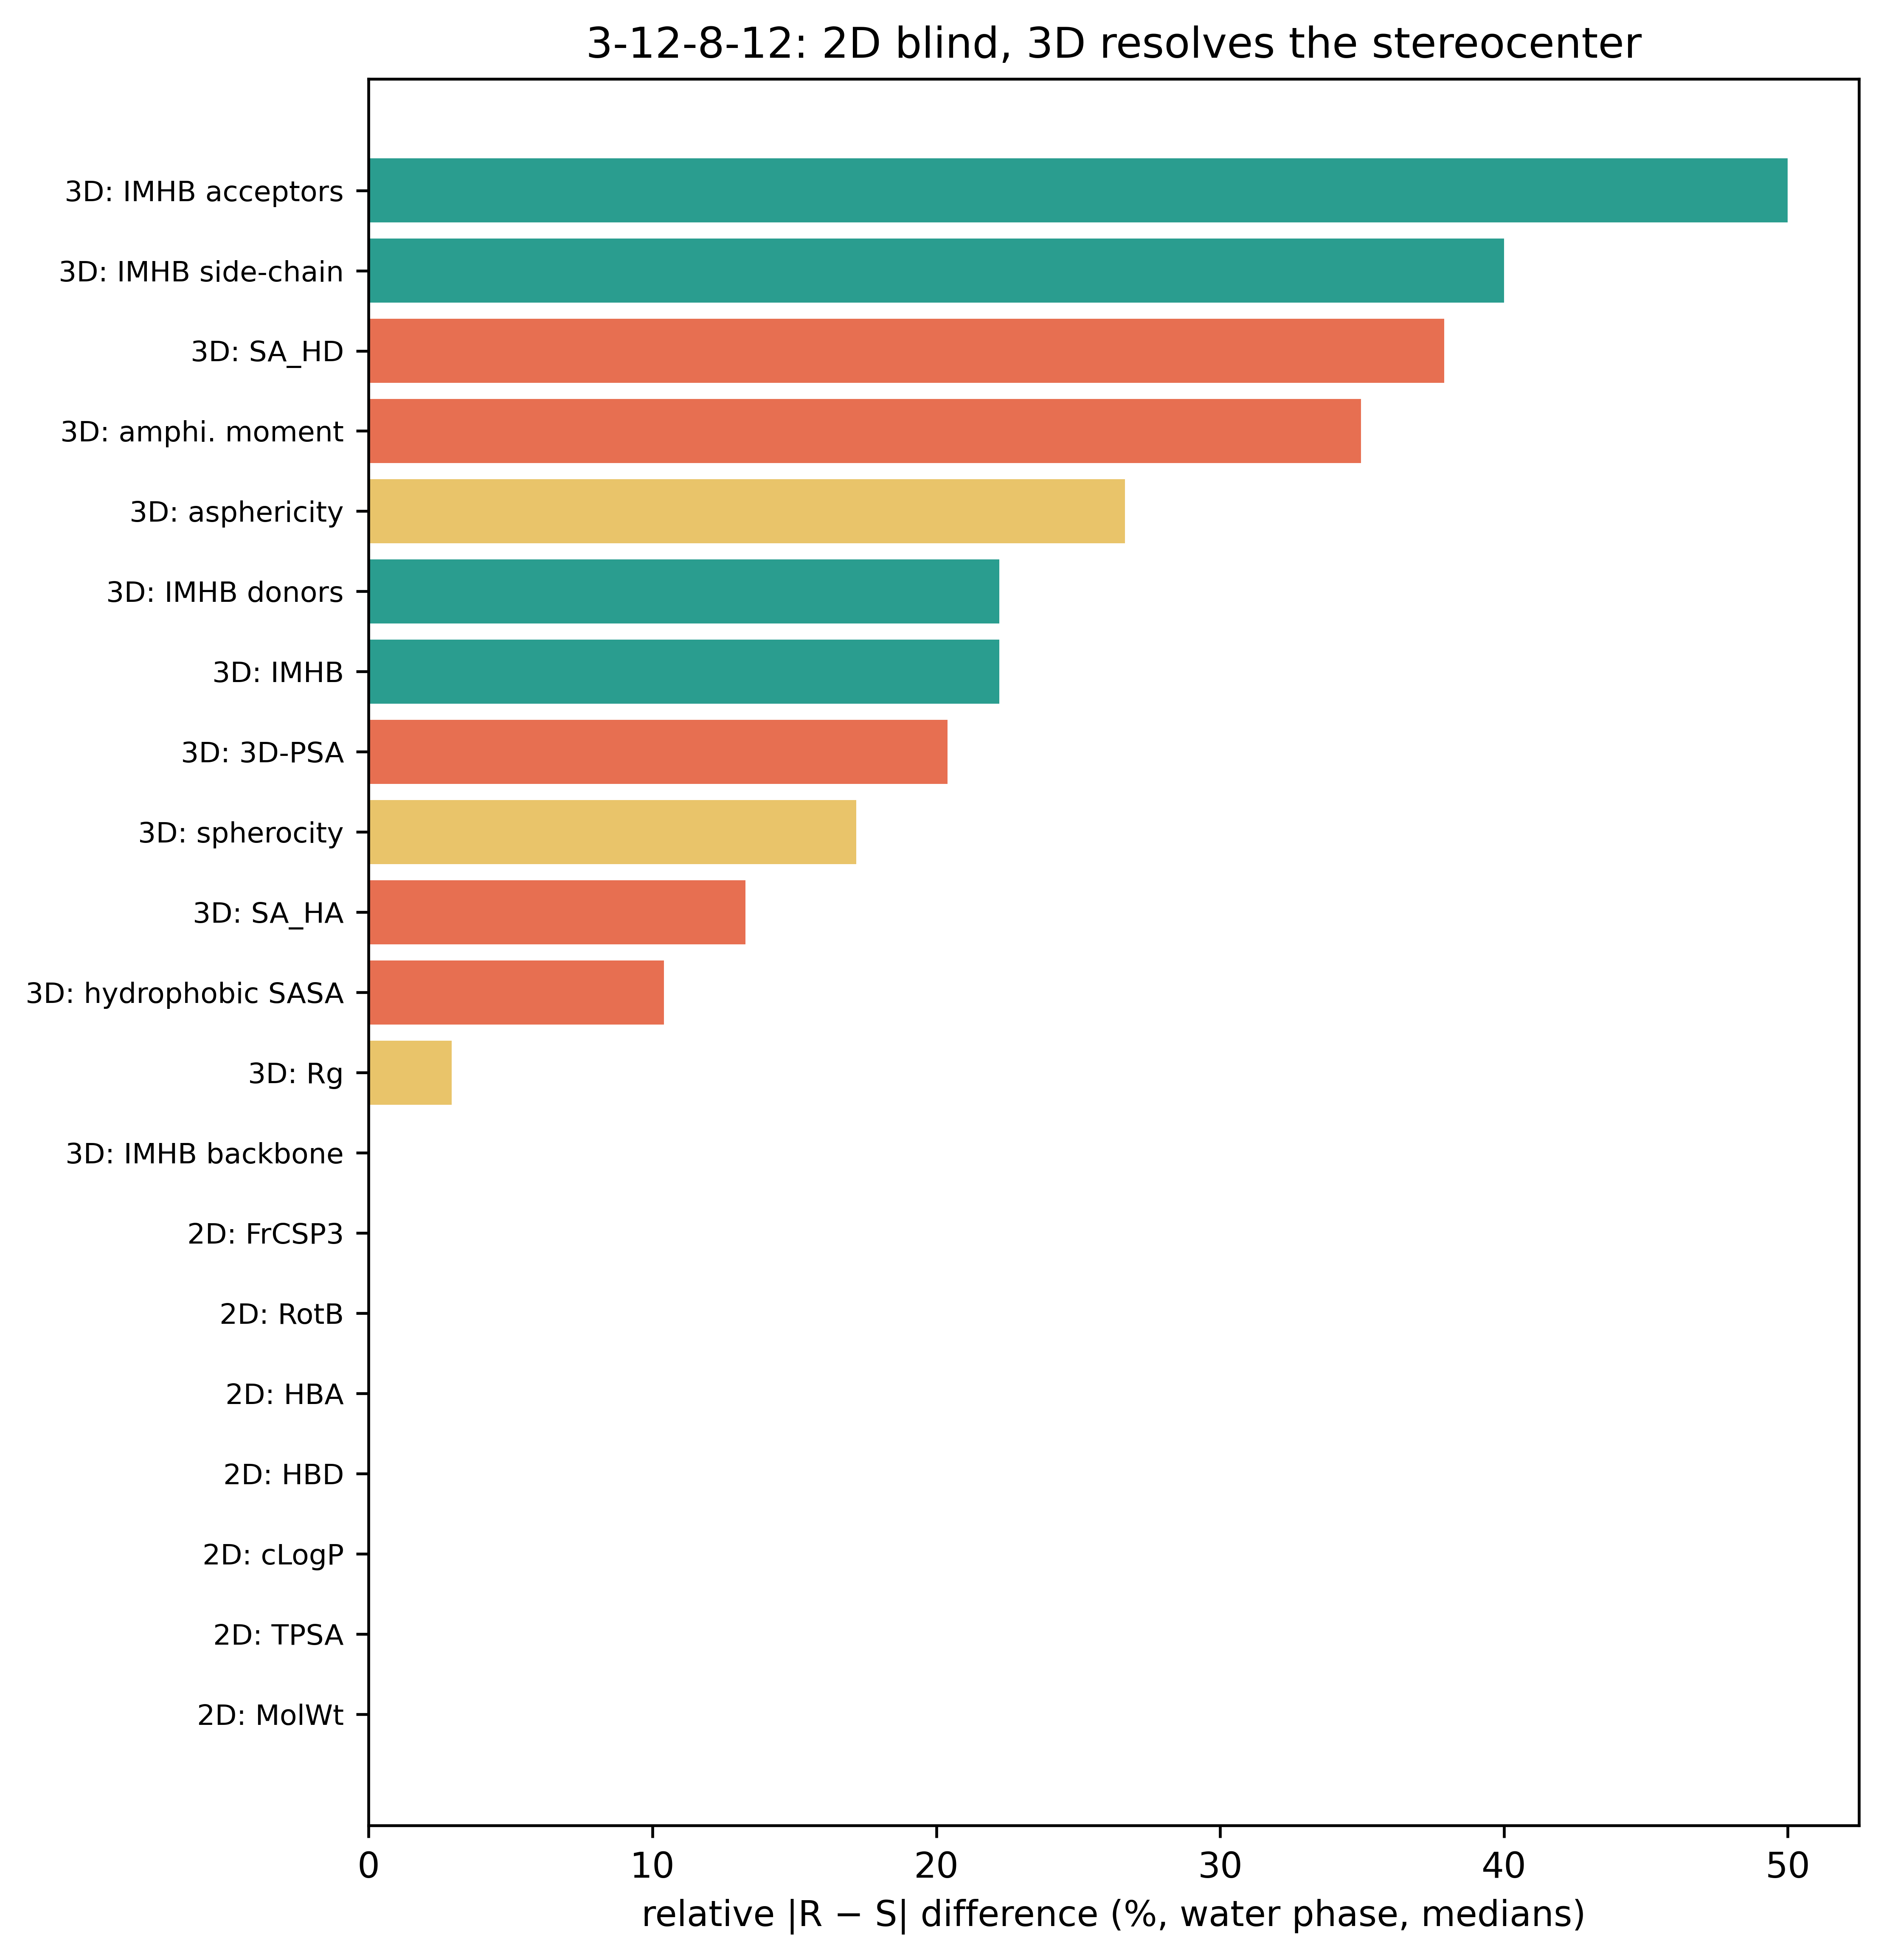

**Fig 2 — SA 3D-PSA and radius of gyration**

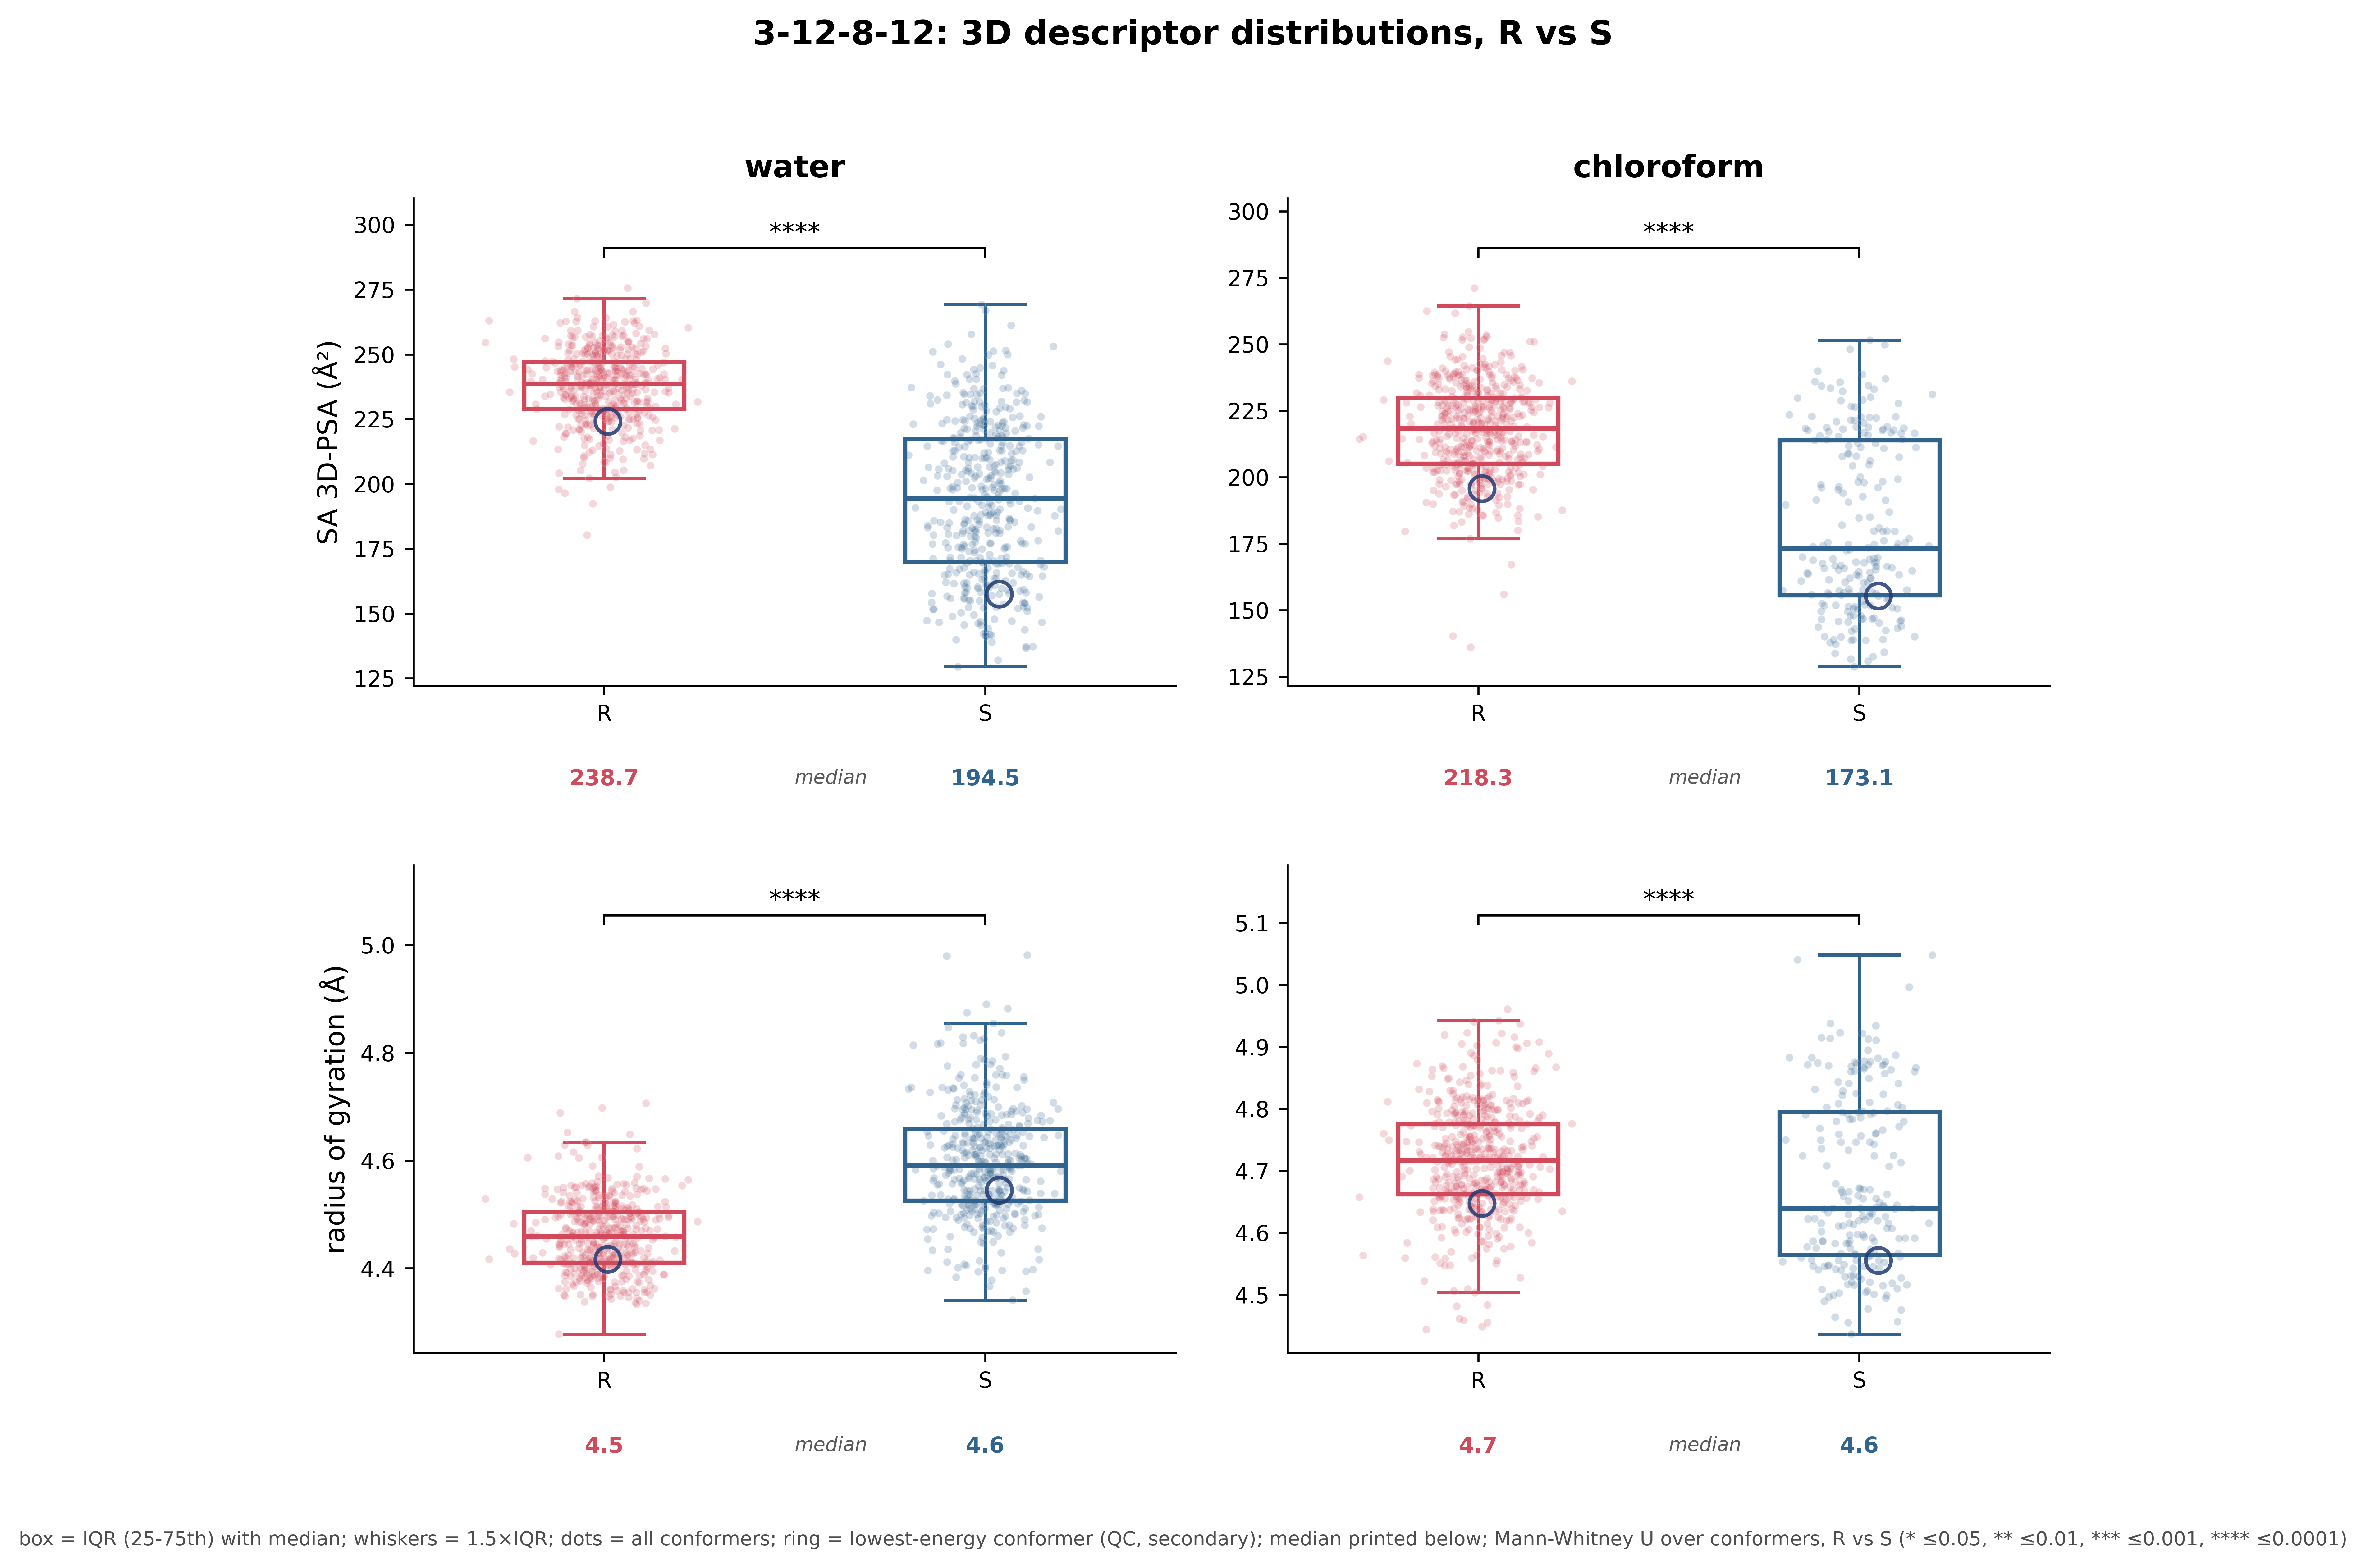

**Fig 3 — backbone IMHB population**

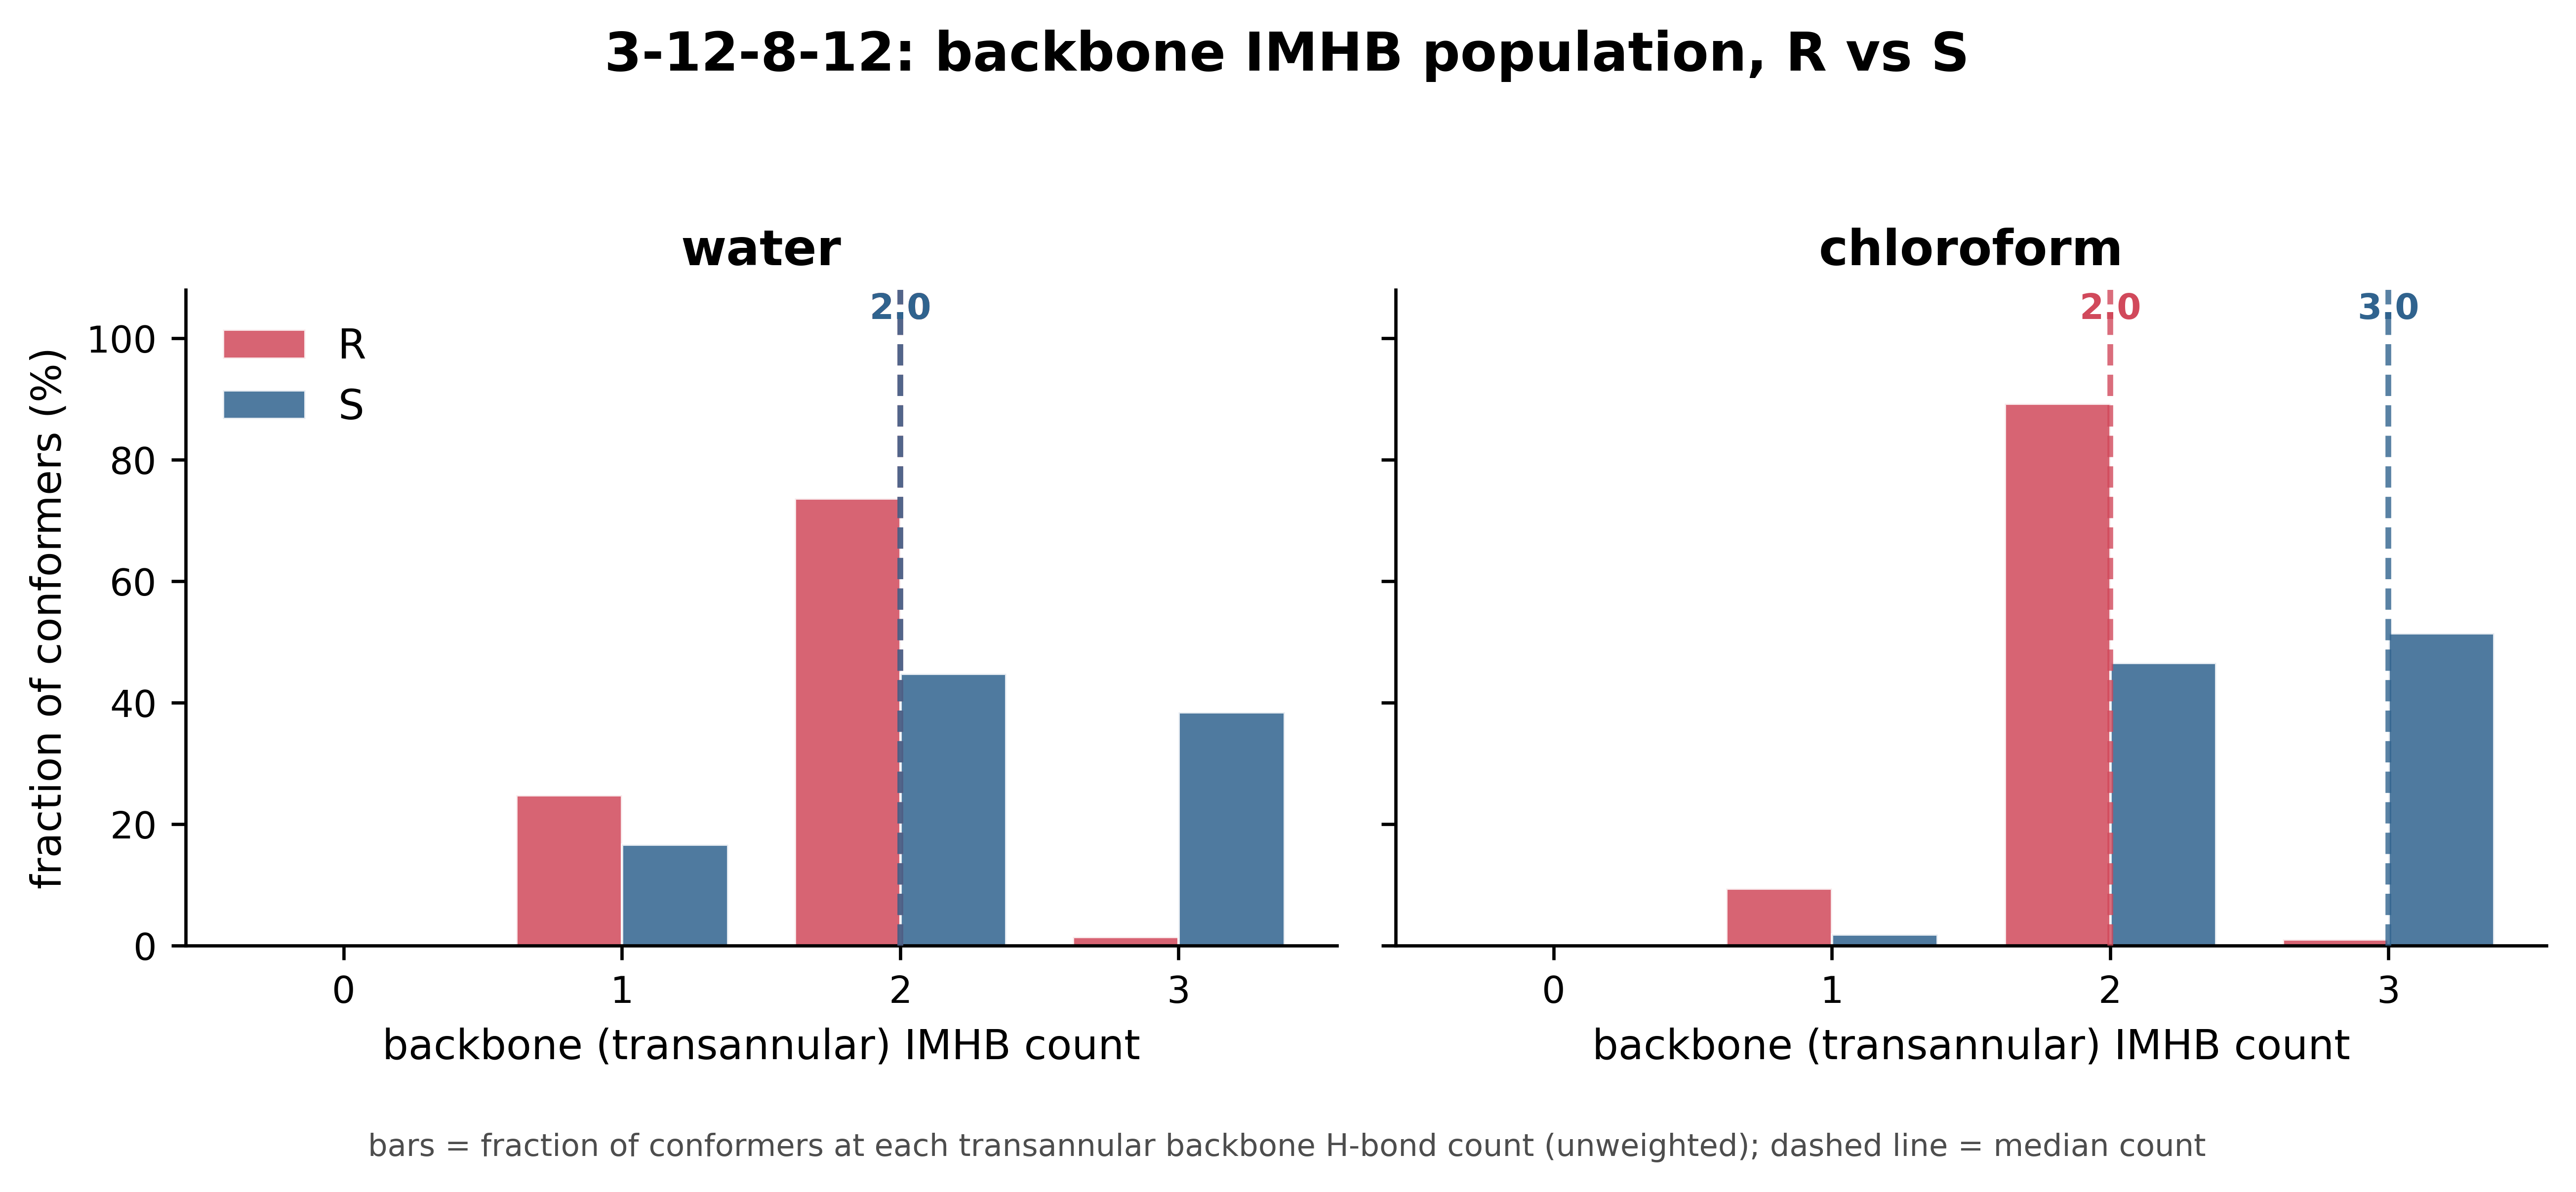

**Fig 4 — PMI shape space**

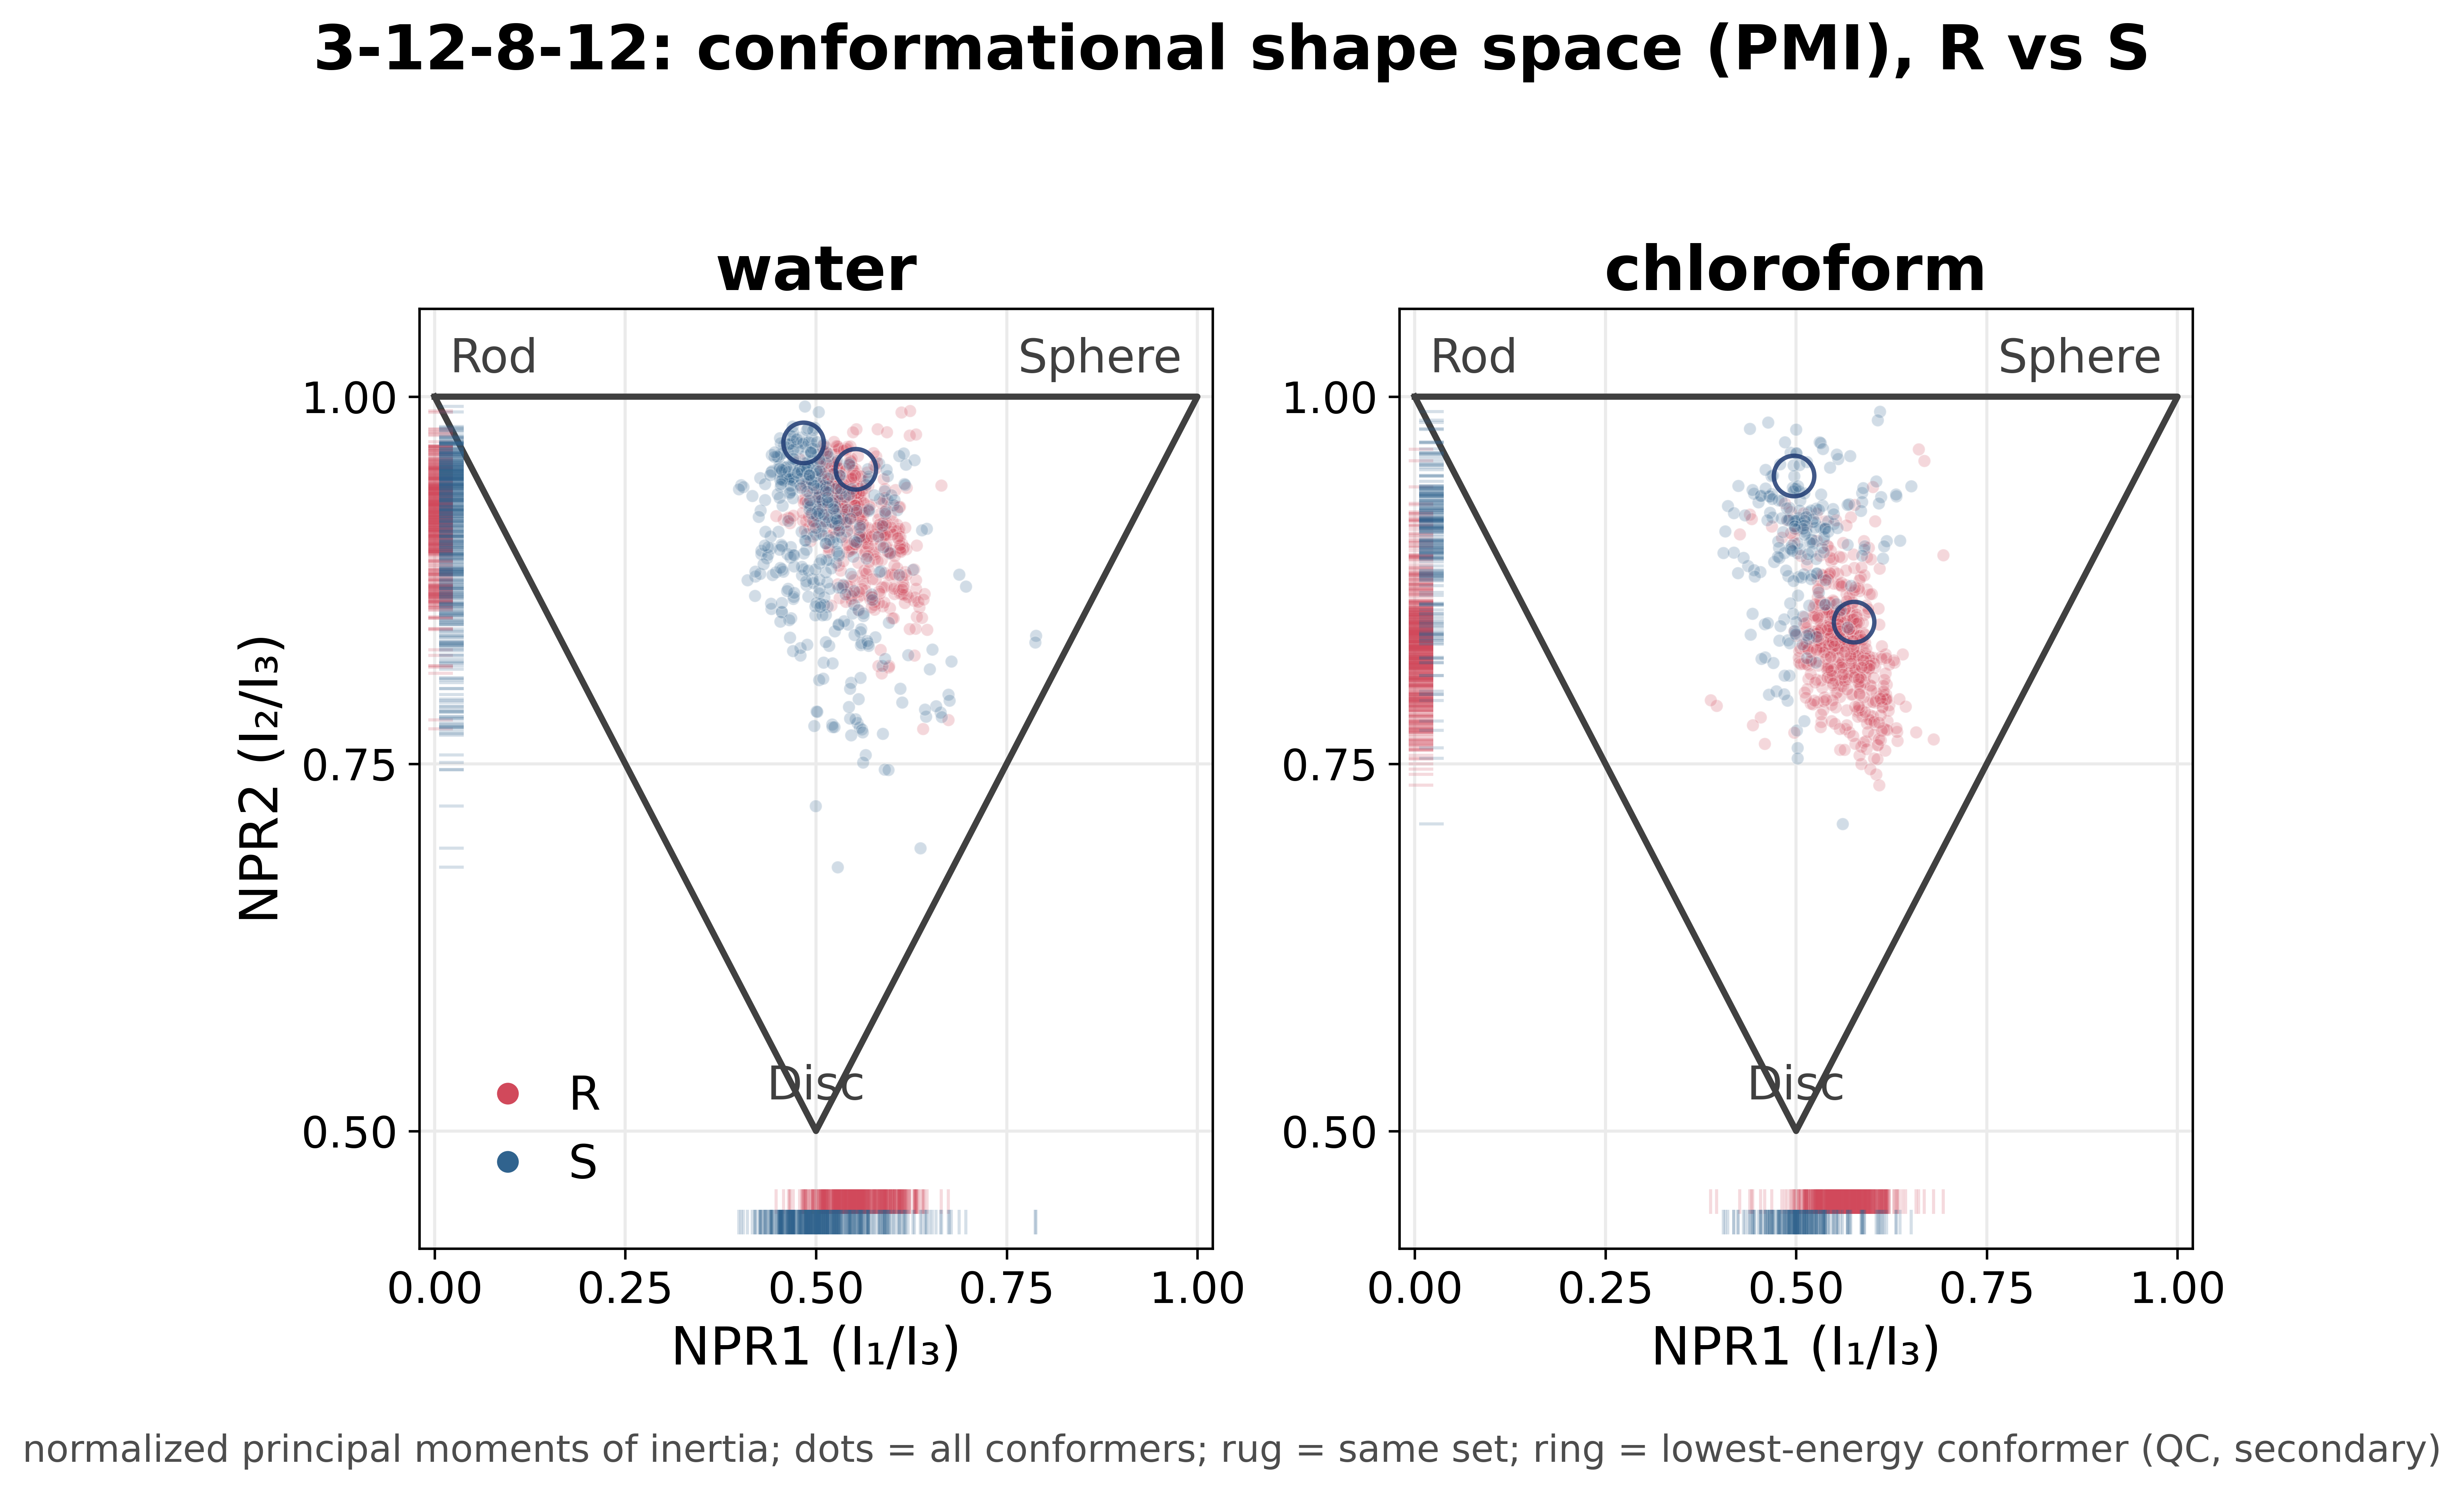

In [4]:
from IPython.display import Image, display, Markdown

for fig, title in [("fig1_reldiff", "Fig 1 — relative |R − S| difference"),
                   ("fig2_key3d",   "Fig 2 — SA 3D-PSA and radius of gyration"),
                   ("fig3_imhb",    "Fig 3 — backbone IMHB population"),
                   ("fig4_pmi",     "Fig 4 — PMI shape space")]:
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(OUT_FIG / f"{fig}.png"), width=720))

---
**Output:** the four report figures (`fig1–fig4`, PNG + SVG) in `results/figures/isomers/<pair>/`.

This completes the pipeline: **generate → calculate → plot**, each stage reading the previous stage's output file.